100%|██████████| 170M/170M [22:54<00:00, 124kB/s]


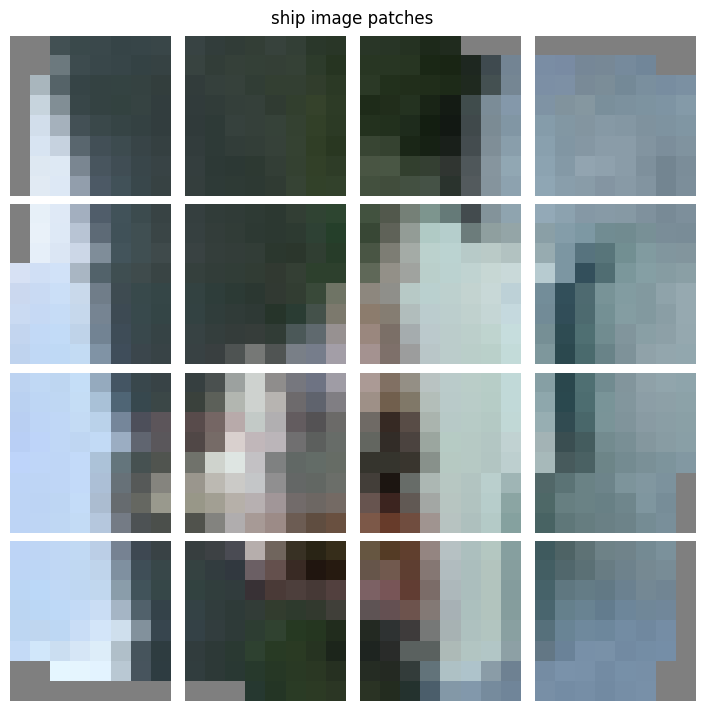

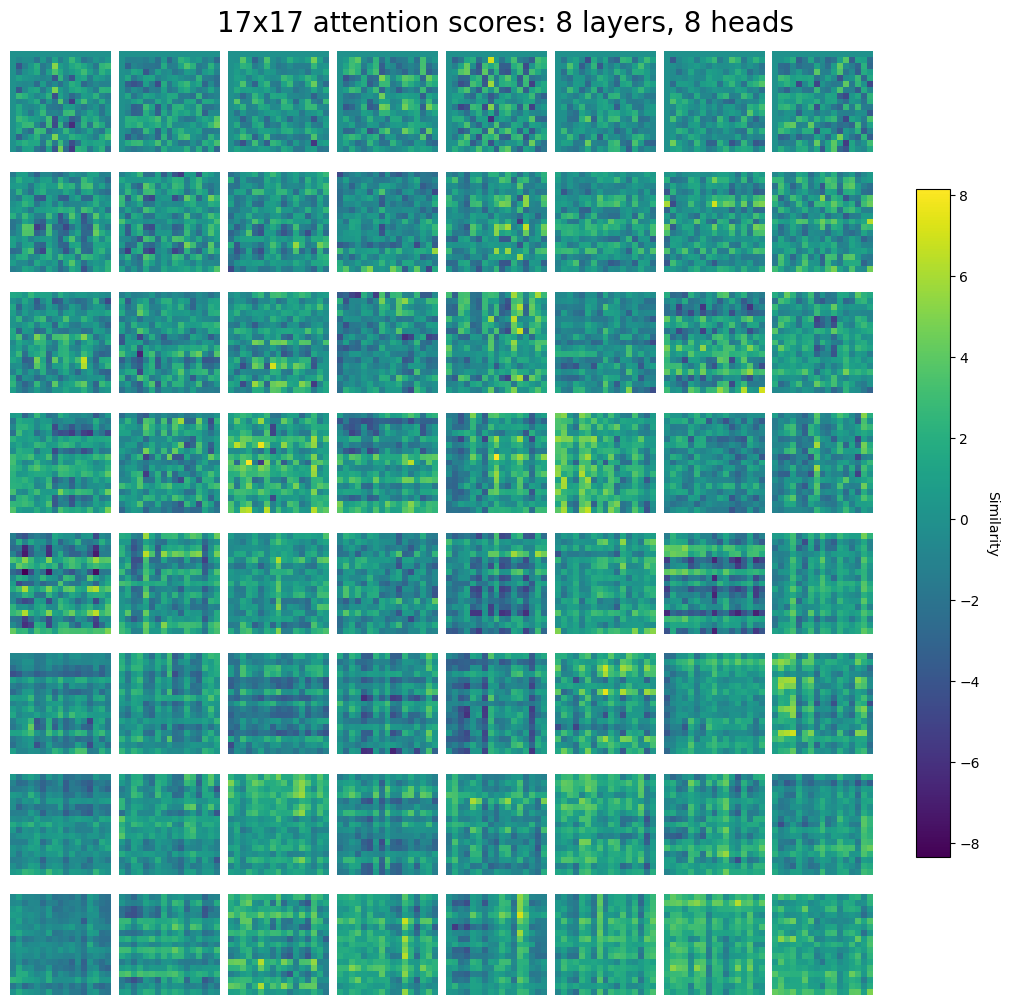

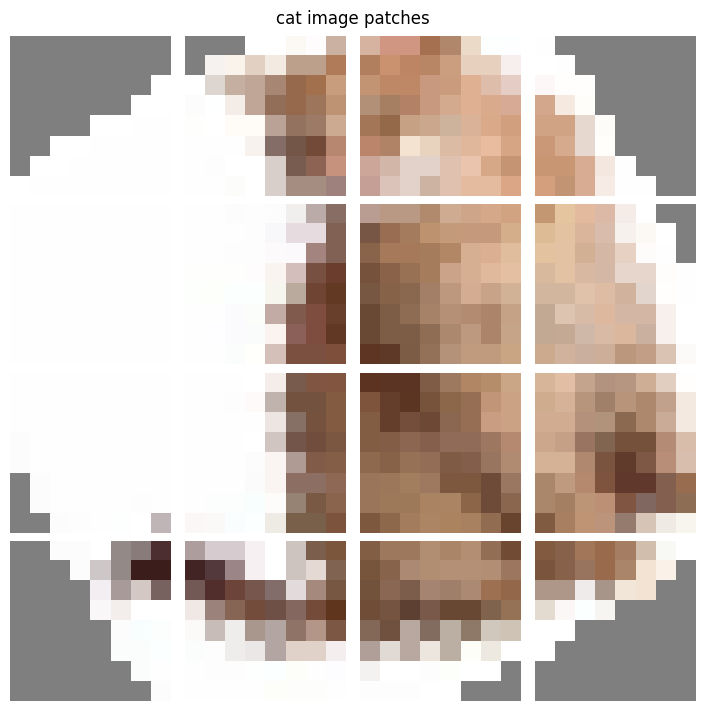

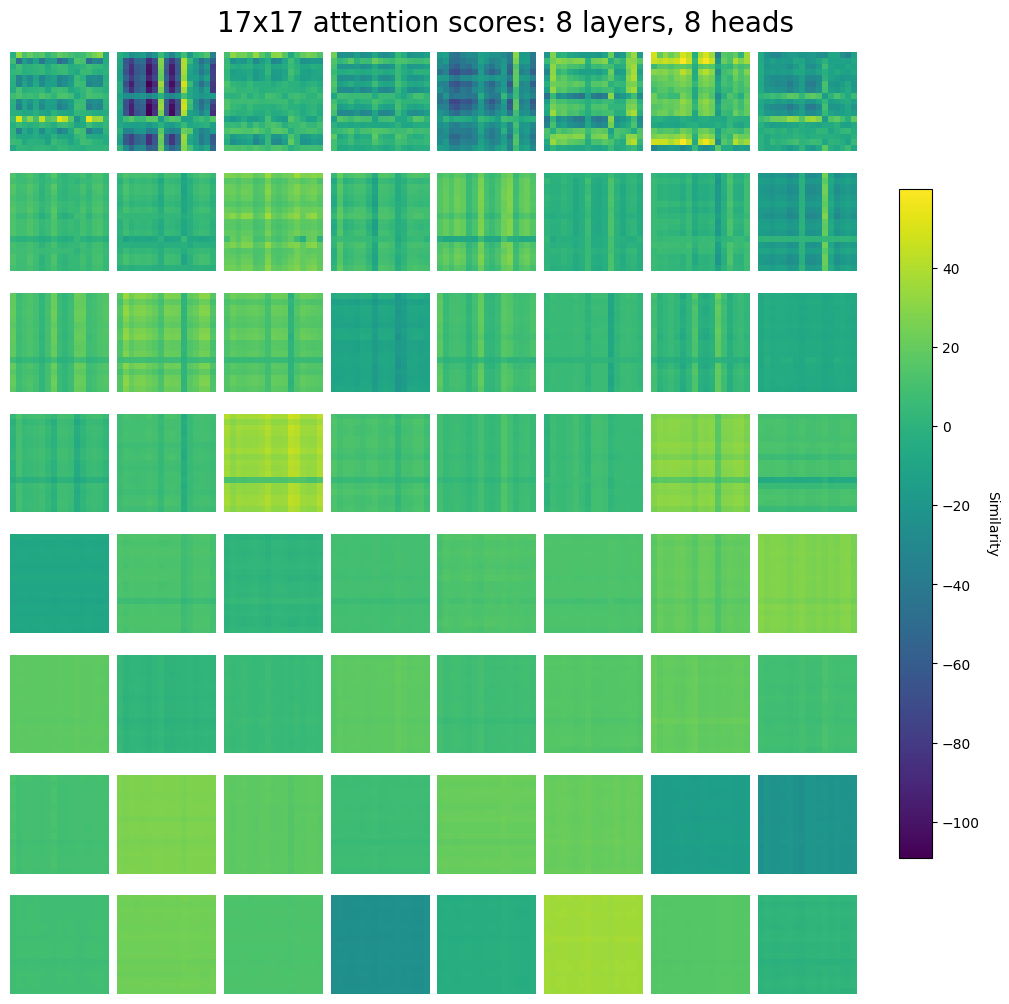

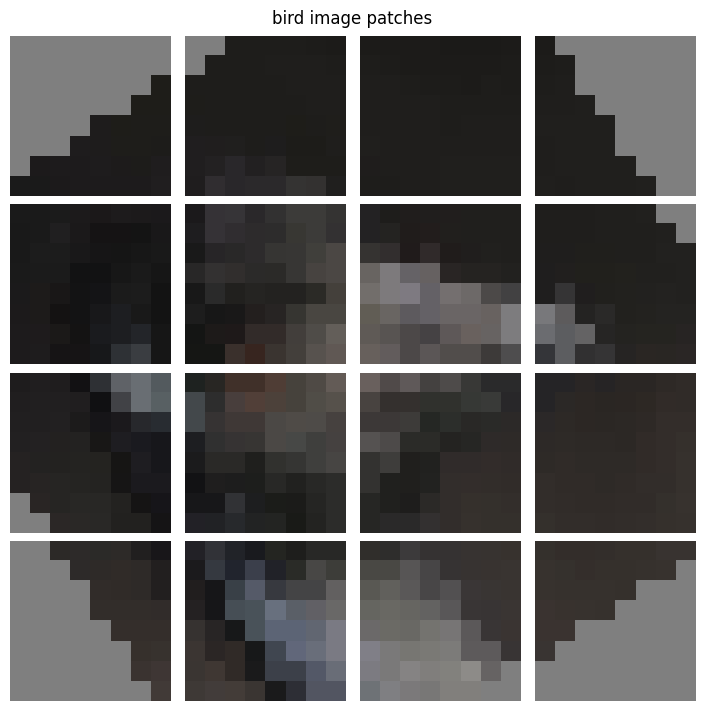

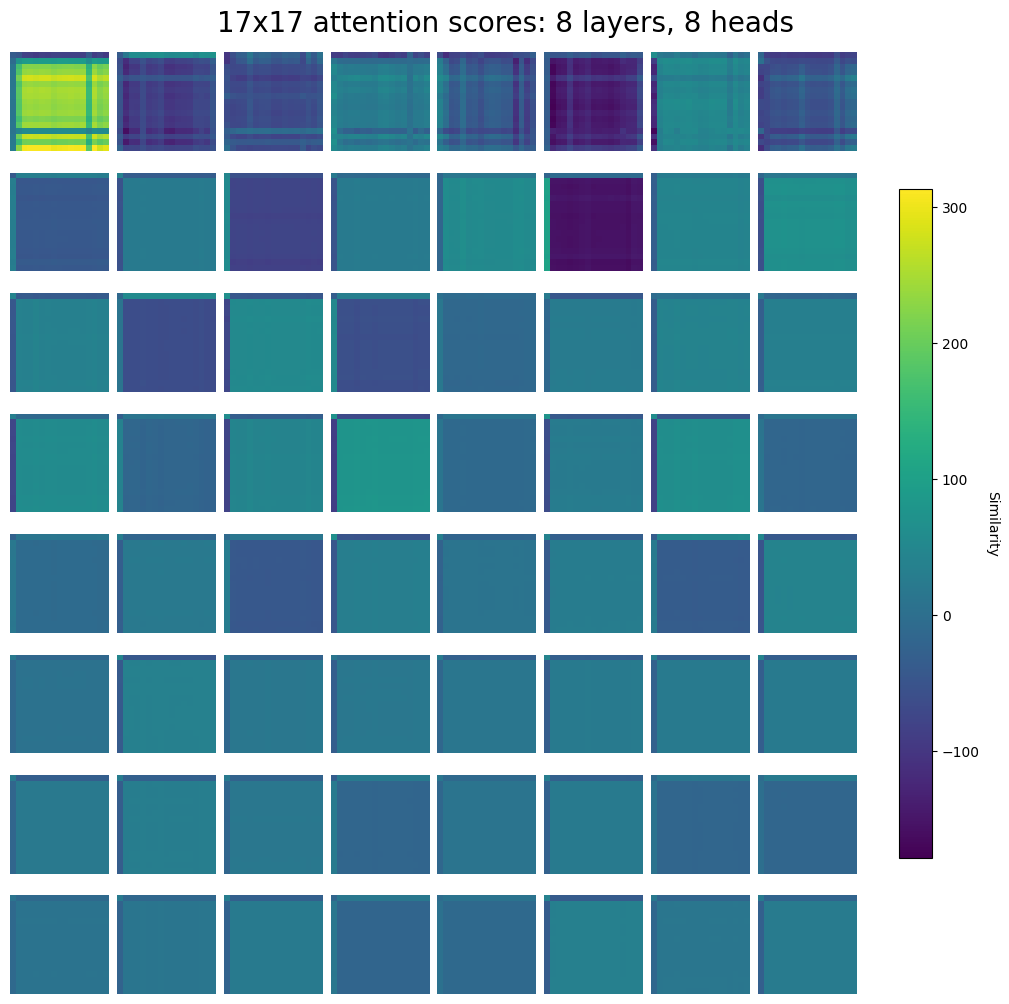

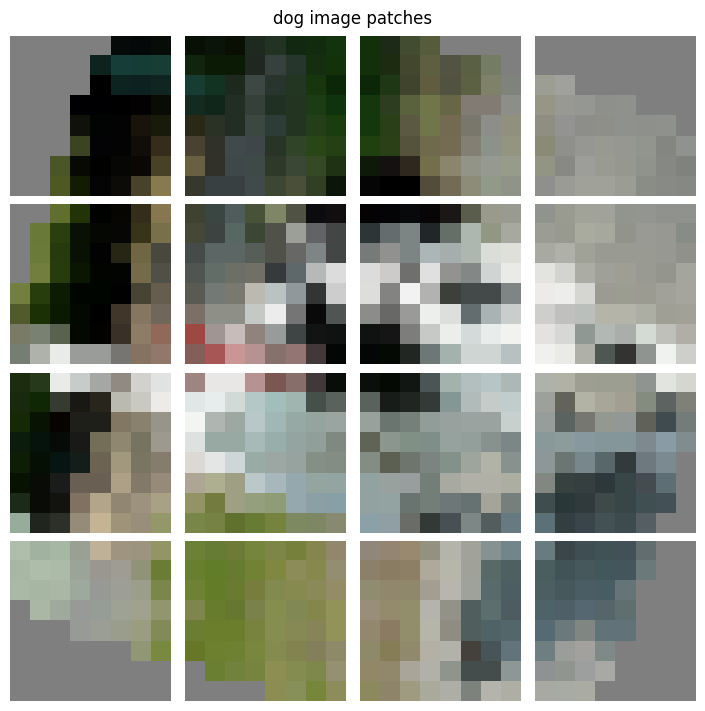

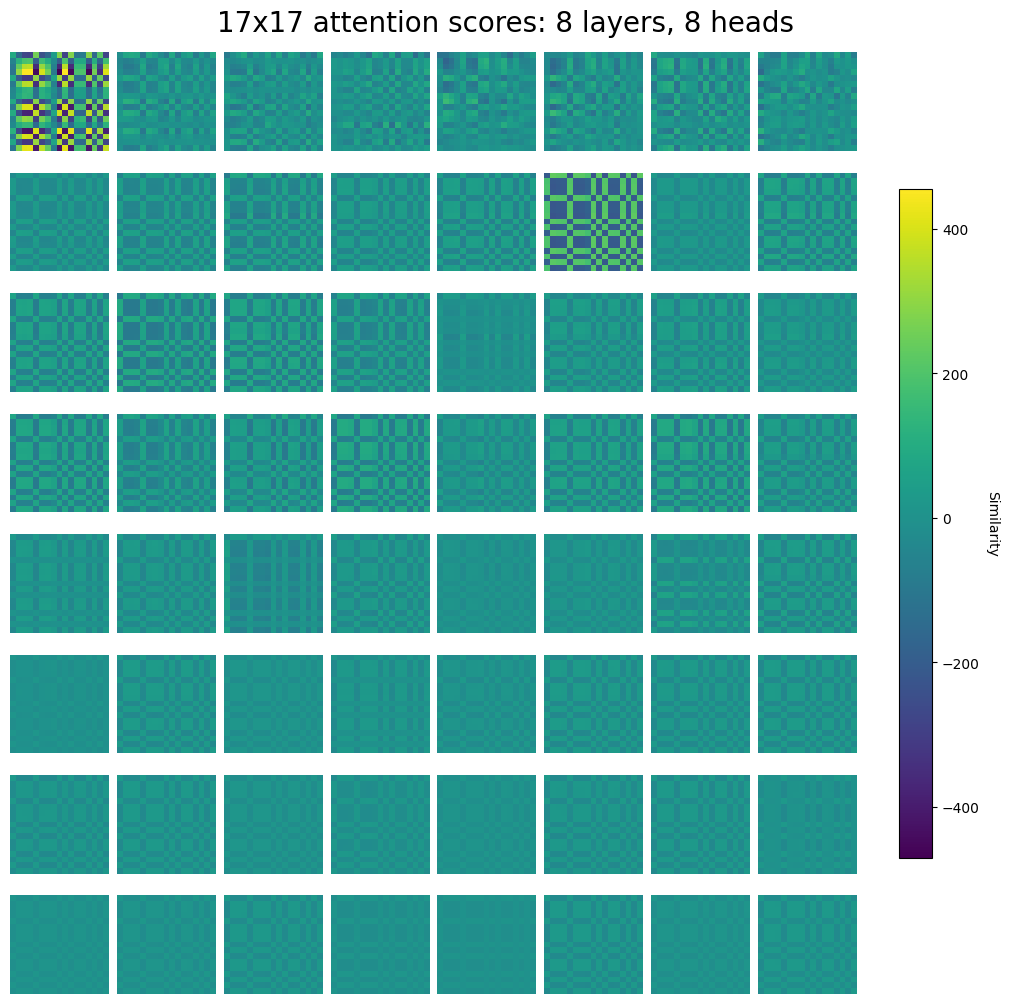

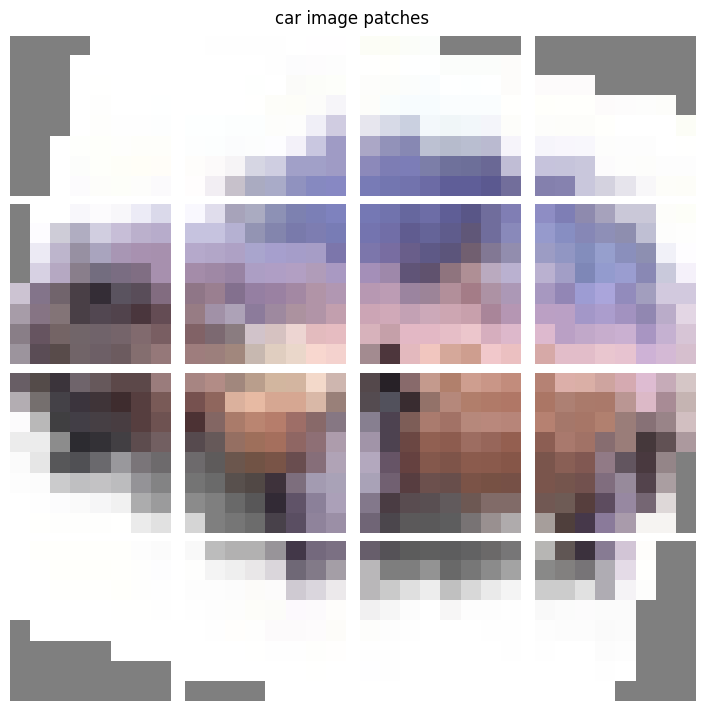

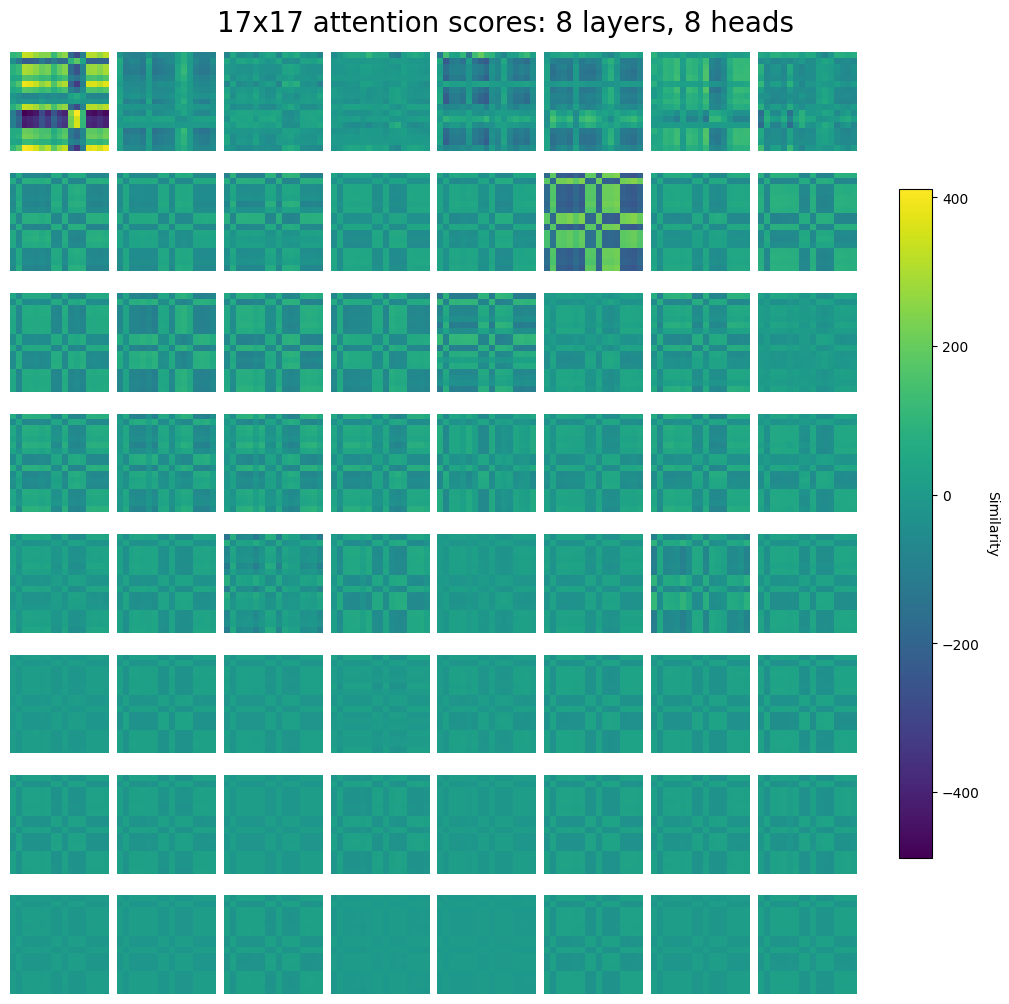

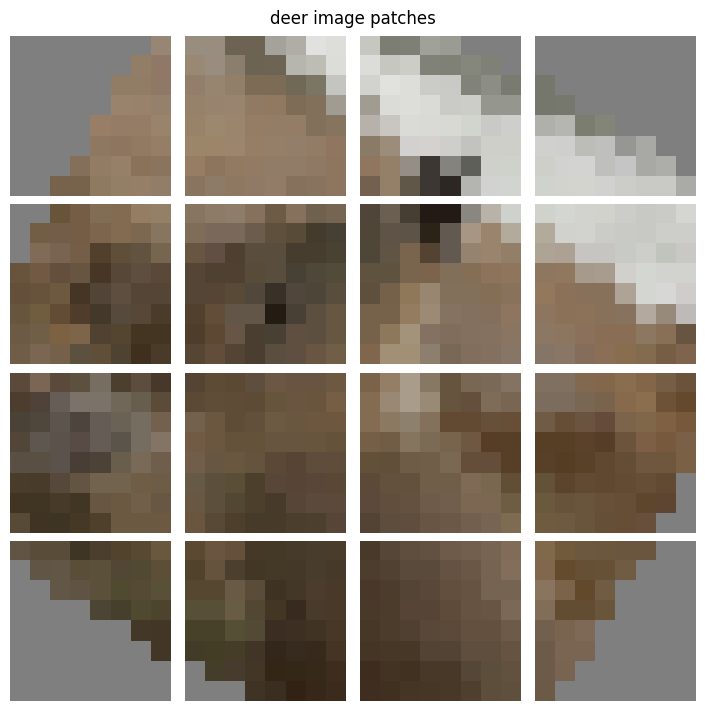

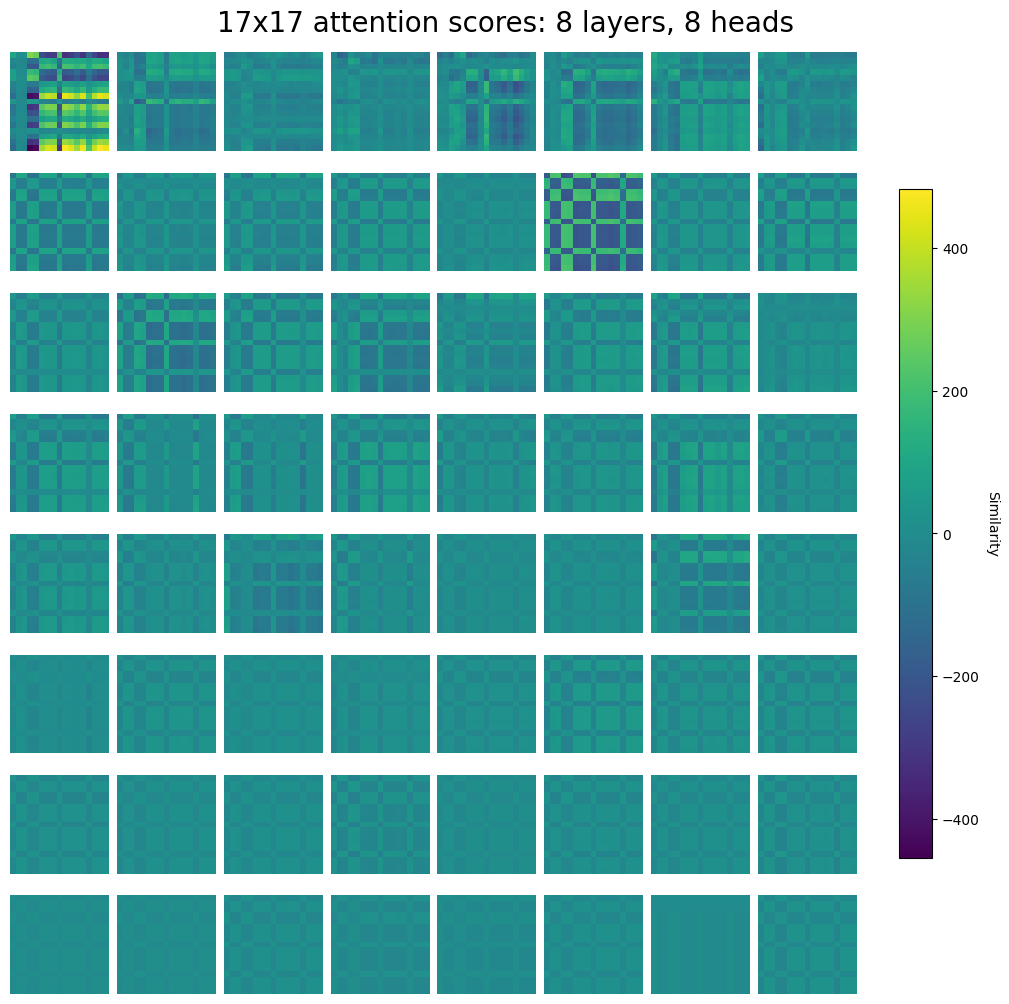

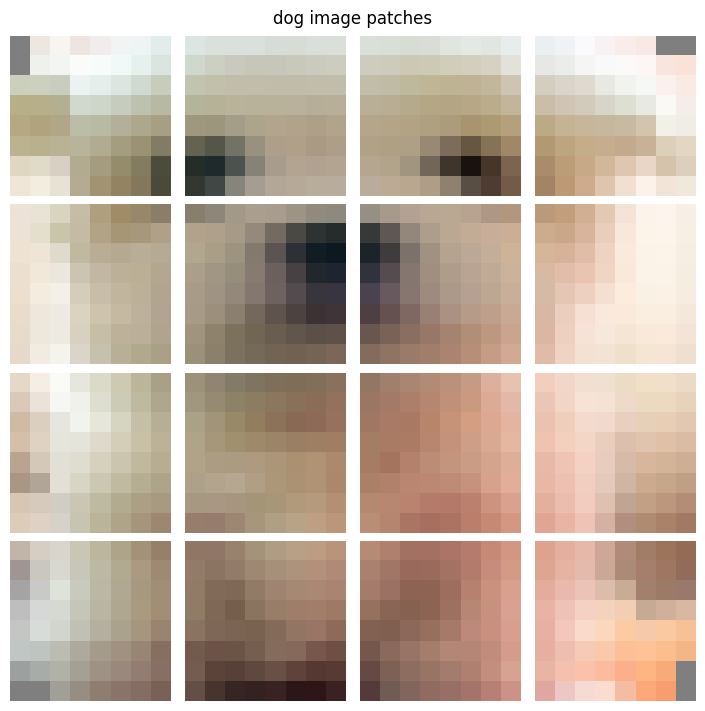

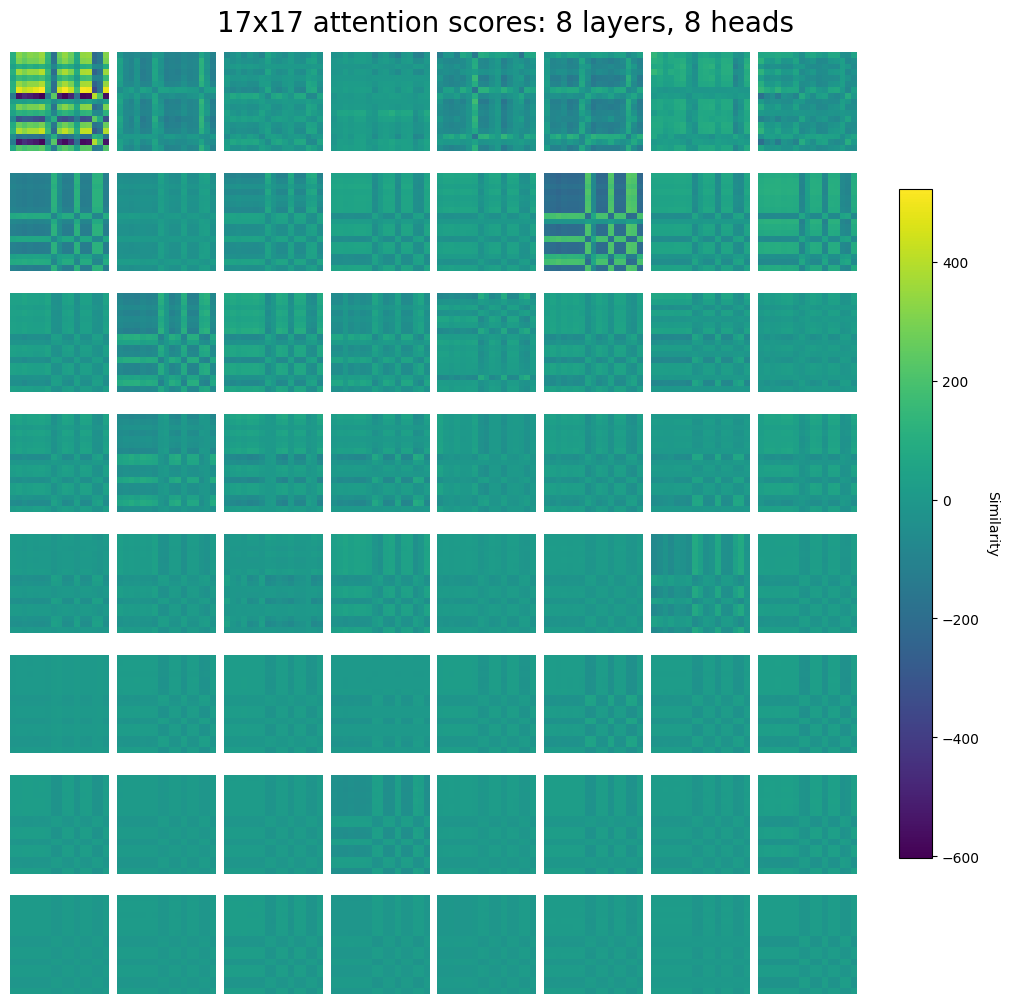

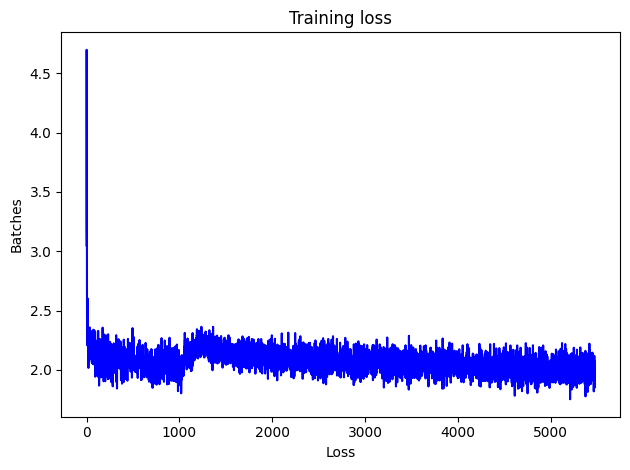

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import math, tomllib, sys

def log_training_progress(batch_idx, epoch, total_epochs, loss, bar_length, loader):
  num_batches = math.ceil(len(loader.dataset) / loader.batch_size)
  batch_count = epoch * num_batches + batch_idx
  progress = batch_count / (total_epochs * num_batches)
  num_bars = progress * bar_length
  progress_bar = '█' * int(num_bars) + ' ' * int(bar_length - num_bars)
  end = "\n" if num_bars == bar_length else "\r"
  info = f"Batch {batch_idx + 1} / {num_batches} | Epoch {epoch} / {total_epochs}"
  print(f"{info} | [{progress_bar}] | Loss: {loss:.3f} \033[K", end=end, flush=True)

def plot_curve(data, title, x_label, y_label, output_path):
  fig, ax = plt.subplots()
  ax.set_title(title)
  ax.set_xlabel(x_label)
  ax.set_ylabel(y_label)
  ax.plot(data, "b-")
  fig.tight_layout()
  fig.savefig(output_path, bbox_inches="tight")
  plt.show()

def patchify_img(img_batch, B, C, P, G):
  # Convert image into a sequence of patches
  patches = img_batch.unfold(2, P, P).unfold(3, P, P)
  patches = patches.contiguous().view(B, C, G * G, P, P)
  patches = patches.permute(0, 2, 3, 4, 1)
  patches = patches.flatten(start_dim=2, end_dim=4)
  return patches

def visualize_patches(i, patch_batch, patch_shape, fig_grid, label, fig_path):
  patches = patch_batch[i]
  N, Px, Py, C = patch_shape
  reshaped = patches.reshape(N, Px, Py, C)

  fig, axs = plt.subplots(nrows=fig_grid[0], ncols=fig_grid[1],
                            figsize=(7, 7), layout="constrained")
  axs = axs.flatten()
  fig.suptitle(f"{label} image patches")

  for i in range(N):
    img = (reshaped[i] + 1) / 2
    axs[i].imshow(img)
    axs[i].axis("off")
  fig.savefig(fig_path)

def visualize_attention_scores(i, layer_score_batch, fig_grid, fig_path):
  fig, axs = plt.subplots(nrows=fig_grid[0], ncols=fig_grid[1],
                          figsize=(10, 10), layout="constrained")
  axs = axs.flatten()

  layer_scores = layer_score_batch[:, i]
  vmin, vmax = layer_scores.min().item(), layer_scores.max().item()
  layers, heads, N = layer_scores.shape[0:3]
  fig.suptitle(f"{N}x{N} attention scores: {layers} layers, {heads} heads", fontsize=20)

  for l in range(layers):
    for h in range(heads):
      idx = l * heads + h
      image = axs[idx].imshow(layer_scores[l, h], vmin=vmin, vmax=vmax)
      axs[idx].axis("off")

  cbar = fig.colorbar(image, ax=axs, location="right", shrink=0.7)
  cbar.ax.set_ylabel("Similarity", va="bottom", rotation=-90)
  fig.savefig(fig_path)

def init_weights(module):
  if isinstance(module, nn.Linear):
    nn.init.kaiming_uniform_(module.weight)
    if module.bias is not None:
      nn.init.zeros_(module.bias)

class MSA(nn.Module):
  def __init__(self, attn_heads, embed_dim):
    super().__init__()
    self.Q_proj = nn.Linear(embed_dim, embed_dim, bias=False)
    self.K_proj = nn.Linear(embed_dim, embed_dim, bias=False)
    self.V_proj = nn.Linear(embed_dim, embed_dim, bias=False)
    self.O_proj = nn.Linear(embed_dim, embed_dim, bias=False)
    self.attn_softmax = nn.Softmax(dim=-1)
    self.variance_scale = 1 / math.sqrt(embed_dim // attn_heads)
    self.H = attn_heads

  # Input and output shape: (B, N + 1, D)
  # D = embedding dimension, H = number of attention heads
  def forward(self, x):
    B, N, D = x.shape
    Q = self.Q_proj(x).view((B, N, self.H, D // self.H)).permute(0, 2, 1, 3)
    K = self.K_proj(x).view((B, N, self.H, D // self.H)).permute(0, 2, 1, 3)
    V = self.V_proj(x).view((B, N, self.H, D // self.H)).permute(0, 2, 1, 3)

    scores = (Q @ K.permute(0, 1, 3, 2)) * self.variance_scale
    output = self.attn_softmax(scores) @ V
    output = output.permute(0, 2, 1, 3).reshape(B, N, D)
    return self.O_proj(output), scores

class ViT(nn.Module):
  def __init__(self, patch_size, grid_size, embed_dim, layers, attn_heads, num_classes):
    super().__init__()
    size = 3 * patch_size * patch_size
    elements = grid_size * grid_size + 1

    self.embed_filters = nn.Linear(size, embed_dim, bias=False)
    self.class_token = nn.Parameter(torch.zeros(embed_dim))
    self.pos_embed = nn.Parameter(torch.zeros(elements, embed_dim))

    self.layers = nn.ModuleList([
      nn.ModuleList([
        nn.LayerNorm(embed_dim),
        MSA(attn_heads, embed_dim),
        nn.LayerNorm(embed_dim),
        nn.Sequential(
          nn.Linear(embed_dim, embed_dim * 4),
          nn.Tanh(),
          nn.Linear(embed_dim * 4, embed_dim)),
      ])
      for _ in range(layers)
    ])

    self.class_norm = nn.LayerNorm(embed_dim)
    self.class_proj = nn.Linear(embed_dim, num_classes)

  # P = patch size, N = patch count, C = channel count
  # B = batch size, O = number of output classes
  # Input shape: (B, N, P * P * C), output shape: (B, O)
  def forward(self, x):
    embeddings = self.embed_filters(x)
    B, N, D = embeddings.shape
    layer_scores = []

    tokens = torch.zeros(B, N + 1, D, device=x.device)
    tokens[:, 0] = self.class_token
    tokens[:, 1:] = embeddings
    z = tokens + self.pos_embed

    for layer in self.layers:
      prev_norm, msa, msa_norm, mlp = layer
      z1, scores = msa(prev_norm(z))
      z1 = z1 + z
      z = mlp(msa_norm(z1)) + z1
      layer_scores.append(scores)

    class_token = self.class_norm(z[:, 0])
    projected = self.class_proj(class_token)
    layer_scores = torch.stack(layer_scores, dim=0)
    return projected, layer_scores

torch.manual_seed(67)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hp = {
  "epochs"         : 7,
  "batch_size"     : 64,
  "learning_rate"  : 1e-3,
  "betas"          : [0.9, 0.999],
  "label_smoothing": 0.1,
  "img_size"       : 32,
  "embedding_dim"  : 256,
  "patch_size"     : 8,
  "attn_heads"     : 8,
  "layers"         : 8,
  "classes"        : ["plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
}

load_pipeline = v2.Compose([
  v2.RGB(), v2.ToImage(),
  v2.ToDtype(torch.float32, scale=True), v2.Resize(size=(32, 32)),
  v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # [0, 255] -> [-1, 1]
])

augment_pipeline = v2.Compose([
  v2.RGB(), v2.ToImage(),
  v2.ToDtype(torch.float32, scale=True), v2.Resize(size=(32, 32)),
  v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)), # [0, 255] -> [-1, 1]
  v2.RandomHorizontalFlip(),
  v2.RandomRotation(90),
  v2.RandomErasing(p=0.3),
])

train_dataset = CIFAR10(root=".cache/train/cifar10", train=True,
                        download=True, transform=augment_pipeline)
train_loader = DataLoader(train_dataset, batch_size=hp["batch_size"], shuffle=True)

model = ViT(
  hp["patch_size"], hp["img_size"] // hp["patch_size"],
  hp["embedding_dim"], hp["layers"], hp["attn_heads"], len(hp["classes"])
).apply(init_weights).to(device)

optimizer = AdamW(model.parameters(), lr=hp["learning_rate"], betas=hp["betas"])
scheduler = CosineAnnealingLR(optimizer, T_max=hp["epochs"])
criterion = nn.CrossEntropyLoss(label_smoothing=hp["label_smoothing"])
losses = []

for epoch in range(hp["epochs"]):
  for i, (images, labels) in enumerate(train_loader):
    # Images shape: (B, C, H, W), Patches shape: (B, N, P, P, C)
    images, labels = images.to(device), labels.to(device)
    patches = patchify_img(
      images, images.shape[0],
      images.shape[1], hp["patch_size"],
      hp["img_size"] // hp["patch_size"]
    )

    class_embeddings, scores = model(patches)
    loss = criterion(class_embeddings, labels)

    losses.append(loss.item())
    log_training_progress(i, epoch, hp["epochs"], loss.item(), 50, train_loader)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad(set_to_none=False)

    # Visualize the change in attention scores as training progresses
    if i == 0:
      idx = torch.randint(hp["batch_size"], size=(1,)).item()
      scores = scores.cpu().detach().numpy()

      G = hp["img_size"] // hp["patch_size"]
      patch_shape = [G * G, hp["patch_size"], hp["patch_size"], 3]
      patch_data = patches.cpu().detach().numpy()
      label = hp["classes"][labels[idx]]

      visualize_patches(idx, patch_data, patch_shape,
                        [G, G], label, f"patches_epoch_{epoch}.png")
      visualize_attention_scores(idx, scores, [hp["layers"], hp["attn_heads"]],
                                 f"scores_epoch_{epoch}.png")

  scheduler.step()

plot_curve(losses, "Training loss", "Loss", "Batches", "train_loss_sample.png")
torch.save(model.state_dict(), ".cache/model-weights.pth")

Thoughts from the first experiment:

- Plot the training loss with a log scale, and state the min, max and median loss
- Should visualize the attention scores post softmax so that the normalized similarities are easier to compare
- Groups of plots should be seperated by folder, ex: "epoch1/patches.png"
- Remove image augmentations for easier debugging
- Grayscale cmap in heatmaps might make more intuitive sense for me?
- Visualize positional embeddings in two ways:
  - Dot product similarity between positions
  - Positional embeddings in full -- I wonder if that'll resemble sinusoidal positional embeddings
- Visualize projected query, keys and values for each projected head and compare that to the unprojected queries, keys and values.
  Can we get a sense of what each head's projections are doing?

- The model failed to fit the dataset:
  - Does the training loss curve show double descent?! The loss kept lowering until about the 1000th
    batch, after which it sharply increased before slowly decreasing again. So maybe the model overfit?
    But at the same time the loss is way too high for that to be a valid possibility...
  - It looks like the attention scores pretty much become uniform after the first epoch. There's definitely
    a bug somewhere...

- Possible fixes:
  - The way that I was prepending the [class] token is not differentiable!! Assigning it to another tensor
    obviously breaks the computational graph. The [class] token probably stayed initialized at zero the entire
    training loop, that's why the loss barely changed. I should be using torch.cat() instead.

  - I don't think the classification head I added is conceptually correct. It's supposed to be a shallow MLP,
    not a linear projection. All I was doing was hoping that the final decoder layer's output would accurately map
    to the classes, no learning was done on that front.

  - Switch from tanh to relu. The magnitude of the attention values (might?) be growing larger each batch,
    so maybe the activation is saturing those values in the mlp.

  - Mimic how the paper visualized positional embeddings: plot the dot product similarity between positions.
  - Another way we can visualize the positional embeddings is to just plot everything in one heatmap. I wonder
    if the learned positional embeddings will resemble sinusoidal embeddings.